In [21]:
import json

import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

metrics_path = Path("../quantization_comparison.json")
with open(metrics_path, "r") as f:
    metrics = json.load(f)

classes = ["Wake", "N1 & N2", "N3", "REM"]

float_m = metrics["float32"]
int_m = metrics["int8"]


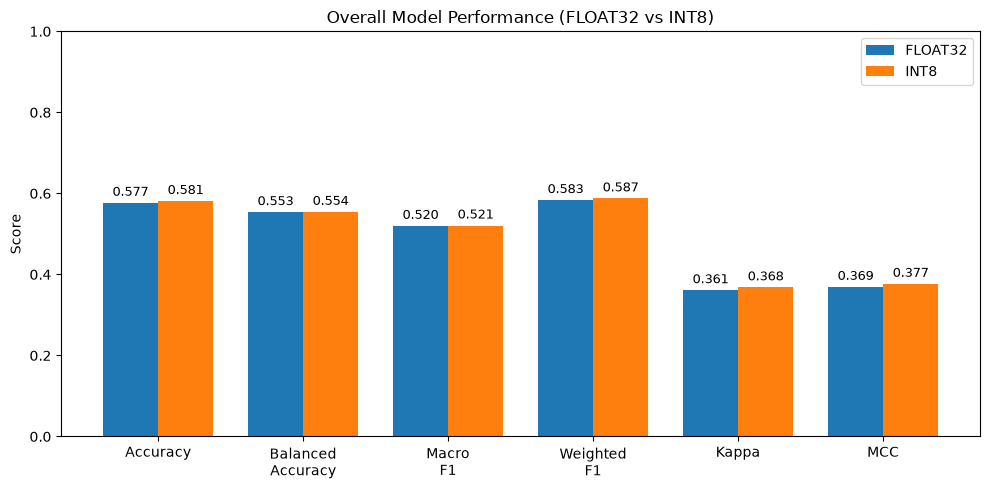

classes: ['Wake', 'N1 & N2', 'N3', 'REM']
len(classes): 4
precision_float: [0.34836066 0.70820089 0.62666667 0.33679354]
len precision: 4
recall_float: [0.42079208 0.53098189 0.76216216 0.5       ]
f1_float: [0.38116592 0.6069191  0.68780488 0.40248105]
[0.3483606557377049, 0.7082008900190718, 0.6266666666666667, 0.33679354094579006]
dict_keys(['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'cohen_kappa', 'mcc', 'precision_per_class', 'recall_per_class', 'f1_per_class', 'support_per_class', 'classification_report'])


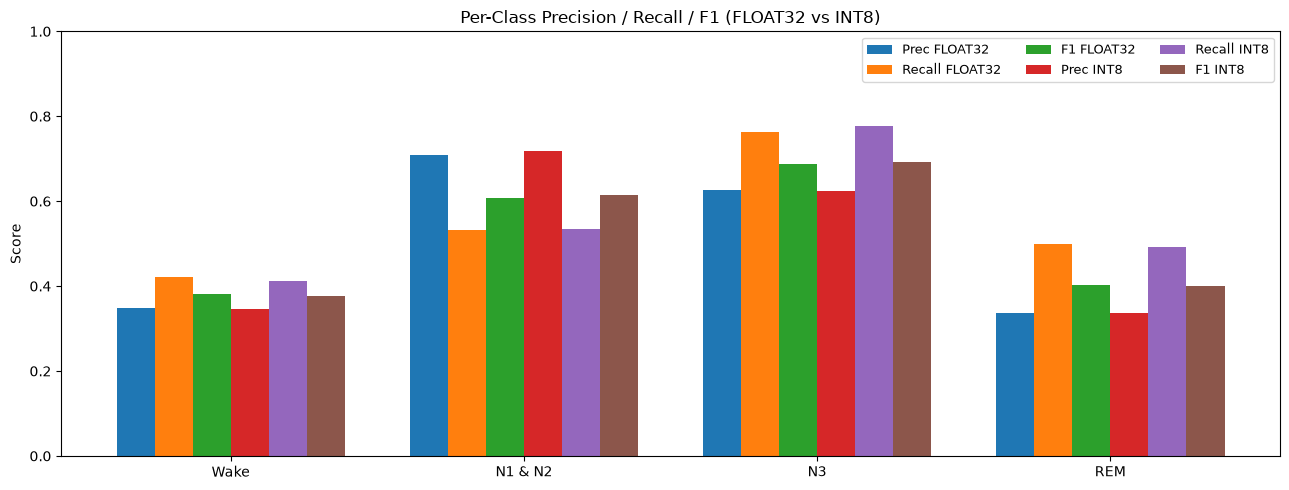

In [22]:
def plot_grouped_overall(overall_float: dict, overall_int8: dict, title: str) -> None:
    keys = list(overall_float.keys())
    x = np.arange(len(keys))
    w = 0.38

    plt.figure(figsize=(10, 5))
    plt.bar(x - w / 2, [overall_float[k] for k in keys], width=w, label="FLOAT32")
    plt.bar(x + w / 2, [overall_int8[k] for k in keys], width=w, label="INT8")

    plt.xticks(x, keys)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()

    # annotate
    for i, k in enumerate(keys):
        for dx, val in [(-w / 2, overall_float[k]), (w / 2, overall_int8[k])]:
            plt.text(i + dx, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

# --- Overall metrics (FLOAT32 vs INT8) ---
overall_float = {
    "Accuracy": float_m["accuracy"],
    "Balanced\nAccuracy": float_m["balanced_accuracy"],
    "Macro\nF1": float_m["f1_macro"],
    "Weighted\nF1": float_m["f1_weighted"],
    "Kappa": float_m["cohen_kappa"],
    "MCC": float_m["mcc"],
}
overall_int8 = {
    "Accuracy": int_m["accuracy"],
    "Balanced\nAccuracy": int_m["balanced_accuracy"],
    "Macro\nF1": int_m["f1_macro"],
    "Weighted\nF1": int_m["f1_weighted"],
    "Kappa": int_m["cohen_kappa"],
    "MCC": int_m["mcc"],
}

plot_grouped_overall(overall_float, overall_int8, "Overall Model Performance (FLOAT32 vs INT8)")

# --- Per-class precision/recall/F1 ---
precision_float = np.array(float_m["precision_per_class"])
recall_float = np.array(float_m["recall_per_class"])
f1_float = np.array(float_m["f1_per_class"])

precision_int8 = np.array(int_m["precision_per_class"])
recall_int8 = np.array(int_m["recall_per_class"])
f1_int8 = np.array(int_m["f1_per_class"])

# Tambahkan jarak antar class
group_spacing = 1      # default 1.0, makin besar makin renggang
x = np.arange(len(classes)) * group_spacing

# Lebar tiap bar
w = 0.13

plt.figure(figsize=(13, 5))

# test print classes
print("classes:", classes)
print("len(classes):", len(classes))

print("precision_float:", precision_float)
print("len precision:", len(precision_float))

print("recall_float:", recall_float)
print("f1_float:", f1_float)

print(float_m["precision_per_class"])
print(float_m.keys())

# FLOAT32
plt.bar(x - 2.5*w, precision_float, width=w, label="Prec FLOAT32")
plt.bar(x - 1.5*w, recall_float,    width=w, label="Recall FLOAT32")
plt.bar(x - 0.5*w, f1_float,        width=w, label="F1 FLOAT32")

# INT8
plt.bar(x + 0.5*w, precision_int8, width=w, label="Prec INT8")
plt.bar(x + 1.5*w, recall_int8,    width=w, label="Recall INT8")
plt.bar(x + 2.5*w, f1_int8,        width=w, label="F1 INT8")

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Per-Class Precision / Recall / F1 (FLOAT32 vs INT8)")
plt.legend(ncol=3, fontsize=9)

plt.tight_layout()
plt.show()


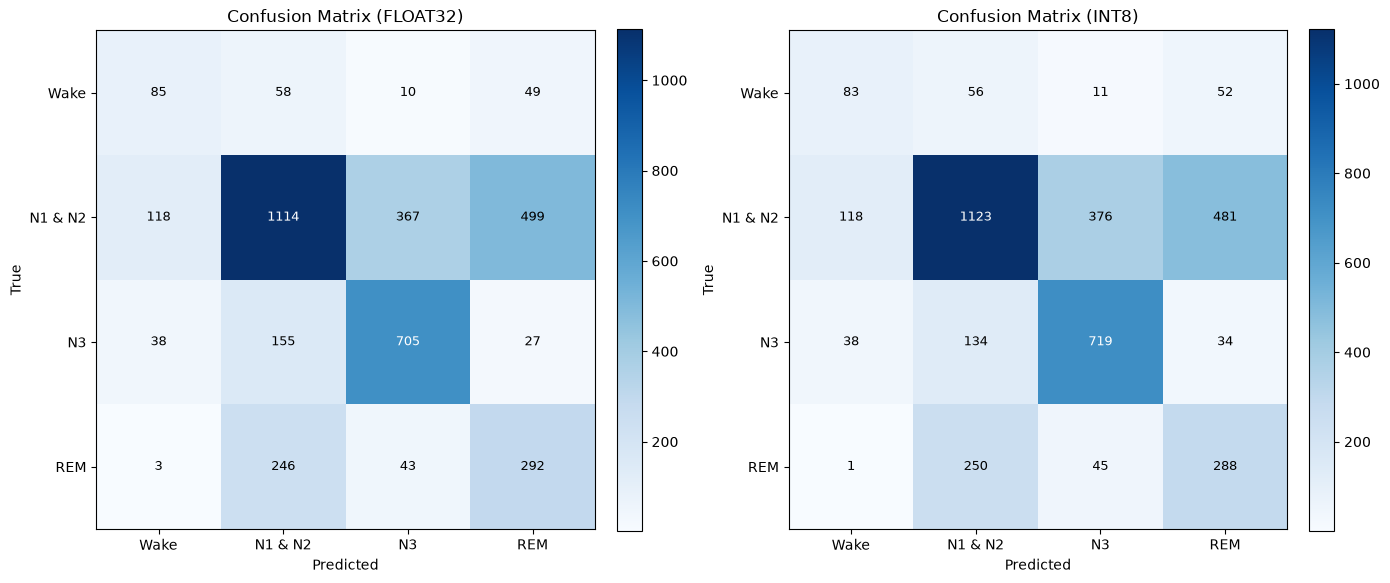

In [23]:
# --- Confusion matrices ---
cm_float = np.array(metrics["float32_confusion_matrix"])
cm_int8 = np.array(metrics["int8_confusion_matrix"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cm, title in [
    (axes[0], cm_float, "Confusion Matrix (FLOAT32)"),
    (axes[1], cm_int8, "Confusion Matrix (INT8)"),
]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(np.arange(len(classes)), labels=classes)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    cm_max = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(int(cm[i, j])),
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm_max / 2 else "black",
                fontsize=9,
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


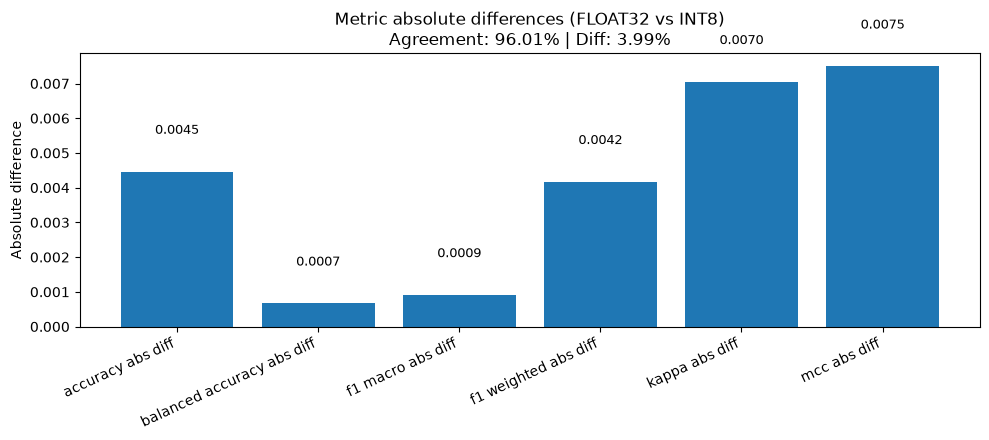

In [24]:
# --- Agreement / differences + abs-diff summary ---
agreement_pct = metrics["prediction_agreement_pct"]
diff_pct = metrics["prediction_difference_pct"]

abs_diffs = metrics.get("metric_abs_differences", {})
keys = [
    "accuracy_abs_diff",
    "balanced_accuracy_abs_diff",
    "f1_macro_abs_diff",
    "f1_weighted_abs_diff",
    "kappa_abs_diff",
    "mcc_abs_diff",
]

plt.figure(figsize=(10, 4.5))
bar_vals = [abs_diffs.get(k, 0.0) for k in keys]
bar = plt.bar([k.replace("_", " ") for k in keys], bar_vals)
plt.ylabel("Absolute difference")
plt.title(
    f"Metric absolute differences (FLOAT32 vs INT8)\nAgreement: {agreement_pct:.2f}% | Diff: {diff_pct:.2f}%"
)
plt.xticks(rotation=25, ha="right")

for b in bar:
    y = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, y + 0.001, f"{y:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## Sleep Stage Error Analysis

The cells below extend the existing comparison notebook with publication-quality analyses for the selected test sequence or subject. The shared helpers reuse `y_true`, `y_pred`, and optional prediction probabilities when they are already present in the notebook state.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception:
    widgets = None
    display = None

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans',
})

CLASS_NAMES = ['Wake', 'Light', 'Deep', 'REM']
DISPLAY_STAGE_ORDER = ['Deep', 'Light', 'REM', 'Wake']
DISPLAY_STAGE_Y = {'Deep': 0, 'Light': 1, 'REM': 2, 'Wake': 3}
STAGE_COLORS = {
    'Wake': '#1f77b4',
    'Light': '#2ca02c',
    'Deep': '#d62728',
    'REM': '#ff7f0e',
}
CORRECT_COLOR = '#2ca02c'
INCORRECT_COLOR = '#d62728'


def _first_global(candidates):
    for name in candidates:
        if name in globals() and globals()[name] is not None:
            return globals()[name], name
    return None, None


def _to_label_array(values):
    arr = np.asarray(values)
    if arr.ndim > 1:
        if arr.shape[-1] == len(CLASS_NAMES):
            arr = arr.argmax(axis=-1)
        else:
            arr = arr.reshape(-1)
    return arr.astype(int).ravel()


def _stage_names(labels):
    labels = _to_label_array(labels)
    return [CLASS_NAMES[int(x)] for x in labels]


def _display_positions(labels):
    names = _stage_names(labels)
    return np.array([DISPLAY_STAGE_Y[name] for name in names], dtype=float)


def _subject_candidates():
    return [
        'subject_ids',
        'subject_id',
        'subjects',
        'test_subject_ids',
        'epoch_subject_ids',
    ]


def _probability_candidates():
    return [
        'y_prob',
        'y_probs',
        'y_proba',
        'y_pred_proba',
        'pred_proba',
        'pred_probs',
        'probabilities',
        'prediction_probabilities',
        'class_probabilities',
    ]


def _segment_runs(mask):
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not mask.any():
        return []
    padded = np.r_[False, mask, False]
    starts = np.where(np.diff(padded.astype(int)) == 1)[0]
    ends = np.where(np.diff(padded.astype(int)) == -1)[0]
    return list(zip(starts, ends))


def _mismatch_runs(y_true, y_pred):
    return _segment_runs(np.asarray(y_true) != np.asarray(y_pred))


def _transition_matrix(labels):
    labels = _to_label_array(labels)
    matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
    if len(labels) > 1:
        for prev_label, next_label in zip(labels[:-1], labels[1:]):
            matrix[int(prev_label), int(next_label)] += 1
    return matrix


def _plot_transition_heatmap(ax, matrix, title):
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('To state')
    ax.set_ylabel('From state')
    ax.set_xticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
    ax.set_yticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)

    max_val = matrix.max() if matrix.size and matrix.max() > 0 else 1
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            color = 'white' if matrix[i, j] > max_val / 2 else 'black'
            ax.text(j, i, str(int(matrix[i, j])), ha='center', va='center', fontsize=9, color=color)
    return im


def _plot_hypnogram(ax, labels, title, line_color='#1f1f1f', mismatch_labels=None):
    labels = _to_label_array(labels)
    y = _display_positions(labels)
    x = np.arange(len(y) + 1)
    y_ext = np.r_[y, y[-1] if len(y) else 0]

    if mismatch_labels is not None:
        for start, end in _mismatch_runs(labels, mismatch_labels):
            ax.axvspan(start, end, color='crimson', alpha=0.10, lw=0)

    ax.step(x, y_ext, where='post', color=line_color, linewidth=2.0)
    ax.set_title(title)
    ax.set_xlabel('Epoch index')
    ax.set_ylabel('Sleep stage')
    ax.set_xlim(0, max(len(labels), 1))
    ax.set_ylim(-0.4, 3.4)
    ax.set_yticks([0, 1, 2, 3], labels=DISPLAY_STAGE_ORDER)
    ax.grid(axis='y', alpha=0.2)


def _sequence_background(ax, y_true, alpha=0.08):
    y_true = _to_label_array(y_true)
    if len(y_true) == 0:
        return
    boundaries = np.r_[0, np.where(y_true[1:] != y_true[:-1])[0] + 1, len(y_true)]
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        stage = CLASS_NAMES[int(y_true[start])]
        ax.axvspan(start, end, color=STAGE_COLORS[stage], alpha=alpha, lw=0)


def _selection_summary(subject_index=0):
    y_true, _ = _first_global(['y_true', 'y_test', 'ground_truth', 'y_val_true'])
    y_pred, _ = _first_global(['y_pred', 'y_hat', 'predictions', 'y_test_pred', 'y_val_pred'])
    if y_true is None or y_pred is None:
        raise RuntimeError(
            'Could not find y_true and y_pred in the notebook state. '
            'Please make sure the evaluation arrays already exist before these visualization cells.'
        )

    y_true = _to_label_array(y_true)
    y_pred = _to_label_array(y_pred)
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    prob_values, _ = _first_global(_probability_candidates())
    y_prob = None
    if prob_values is not None:
        prob_values = np.asarray(prob_values)
        if prob_values.ndim == 2 and prob_values.shape[0] >= n and prob_values.shape[1] == len(CLASS_NAMES):
            y_prob = prob_values[:n]
        elif prob_values.ndim == 3 and prob_values.shape[-1] == len(CLASS_NAMES):
            y_prob = prob_values.reshape(-1, prob_values.shape[-1])[:n]

    subject_values, subject_name = _first_global(_subject_candidates())
    subject_label = 'all available test epochs'
    subject_ids_available = False
    if subject_values is not None:
        subject_values = np.asarray(subject_values)
        if subject_values.ndim > 0 and subject_values.shape[0] >= n:
            subject_ids_available = True
            subject_values = subject_values[:n]
            unique_subjects = np.unique(subject_values)
            if unique_subjects.size > 0:
                selected_index = int(np.clip(subject_index, 0, unique_subjects.size - 1))
                selected_subject = unique_subjects[selected_index]
                mask = subject_values == selected_subject
                if mask.any():
                    y_true = y_true[mask]
                    y_pred = y_pred[mask]
                    if y_prob is not None and len(y_prob) >= len(mask):
                        y_prob = y_prob[mask]
                    subject_label = f'{subject_name}={selected_subject}'
    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'subject_label': subject_label,
        'has_subject_ids': subject_ids_available,
    }


def _selected_confusion_matrix(y_true, y_pred):
    return confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))


def _plot_categorical_timeline(ax, labels, title, row_label):
    labels = _to_label_array(labels)
    arr = labels[np.newaxis, :]
    cmap = ListedColormap([STAGE_COLORS[name] for name in CLASS_NAMES])
    ax.imshow(arr, aspect='auto', cmap=cmap, vmin=0, vmax=len(CLASS_NAMES) - 1, interpolation='nearest')
    ax.set_yticks([])
    ax.set_ylabel(row_label, rotation=0, labelpad=40, va='center')
    ax.set_title(title)
    ax.set_xlim(-0.5, max(len(labels) - 0.5, 0.5))
    ax.set_xticks(np.linspace(0, max(len(labels) - 1, 0), num=min(10, max(len(labels), 1)), dtype=int))
    ax.set_xlabel('Epoch index')
    ax.grid(False)


def _plot_binary_timeline(ax, correct_mask, title, row_label):
    correct_mask = np.asarray(correct_mask, dtype=int)
    arr = correct_mask[np.newaxis, :]
    cmap = ListedColormap([INCORRECT_COLOR, CORRECT_COLOR])
    ax.imshow(arr, aspect='auto', cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.set_yticks([])
    ax.set_ylabel(row_label, rotation=0, labelpad=40, va='center')
    if title:
        ax.set_title(title)
    ax.set_xlim(-0.5, max(len(correct_mask) - 0.5, 0.5))
    ax.set_xticks(np.linspace(0, max(len(correct_mask) - 1, 0), num=min(10, max(len(correct_mask), 1)), dtype=int))
    ax.set_xlabel('Epoch index')


def plot_probability_panels(y_true, y_prob, subject_label):
    if y_prob is None:
        print('Prediction probabilities are not available; skipping class probability plot.')
        return False

    y_true = _to_label_array(y_true)
    y_prob = np.asarray(y_prob)
    if y_prob.ndim != 2 or y_prob.shape[1] != len(CLASS_NAMES):
        print('Prediction probabilities are not in the expected shape (n_epochs, 4); skipping class probability plot.')
        return False

    x = np.arange(len(y_true))
    fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 11), sharex=True)
    fig.suptitle(f'Class Probability Trajectories - {subject_label}', fontsize=15, y=0.995)

    for idx, (ax, class_name) in enumerate(zip(axes, CLASS_NAMES)):
        _sequence_background(ax, y_true, alpha=0.07)
        ax.plot(x, y_prob[:, idx], color=STAGE_COLORS[class_name], linewidth=2.0, label=f'P({class_name})')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(class_name)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(loc='upper right', frameon=False)
        if idx == 0:
            ax.set_title(f'Per-class probabilities with true stage background - {subject_label}')

    axes[-1].set_xlabel('Epoch index')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    return True


def plot_per_class_accuracy(y_true, y_pred, subject_label):
    y_true = _to_label_array(y_true)
    y_pred = _to_label_array(y_pred)
    accuracies = []
    supports = []
    for class_index in range(len(CLASS_NAMES)):
        mask = y_true == class_index
        supports.append(int(mask.sum()))
        accuracies.append(float((y_true[mask] == y_pred[mask]).mean()) if mask.any() else np.nan)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(CLASS_NAMES, accuracies, color=[STAGE_COLORS[name] for name in CLASS_NAMES], edgecolor='black', linewidth=0.6)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Per-class accuracy')
    ax.set_title(f'Per-Class Accuracy - {subject_label}')
    ax.grid(axis='y', alpha=0.2)

    for bar, accuracy, support in zip(bars, accuracies, supports):
        if np.isnan(accuracy):
            label = 'N/A'
            height = 0.02
        else:
            label = f'{accuracy * 100:.1f}%\n(n={support})'
            height = accuracy
        ax.text(bar.get_x() + bar.get_width() / 2, min(height + 0.03, 0.98), label, ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_transition_analysis(y_true, y_pred, subject_label):
    true_matrix = _transition_matrix(y_true)
    pred_matrix = _transition_matrix(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    fig.suptitle(f'Transition Error Analysis - {subject_label}', fontsize=15)
    im1 = _plot_transition_heatmap(axes[0], true_matrix, 'Ground Truth Transitions')
    im2 = _plot_transition_heatmap(axes[1], pred_matrix, 'Predicted Transitions')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Count')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Count')
    plt.show()


def longest_error_segment(y_true, y_pred):
    y_true = _to_label_array(y_true)
    y_pred = _to_label_array(y_pred)
    mismatch = y_true != y_pred
    runs = _segment_runs(mismatch)
    if not runs:
        return None
    start, end = max(runs, key=lambda pair: pair[1] - pair[0])
    return {
        'start': int(start),
        'end': int(end - 1),
        'length': int(end - start),
        'y_true': y_true[start:end],
        'y_pred': y_pred[start:end],
    }


def print_error_statistics(y_true, y_pred, subject_label):
    y_true = _to_label_array(y_true)
    y_pred = _to_label_array(y_pred)
    total_epochs = int(len(y_true))
    correct = int((y_true == y_pred).sum())
    incorrect = int(total_epochs - correct)
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro_support, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = _selected_confusion_matrix(y_true, y_pred)

    print(f'Subject / sequence: {subject_label}')
    print(f'Total epochs: {total_epochs}')
    print(f'Correct predictions: {correct}')
    print(f'Incorrect predictions: {incorrect}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
    print(f'Precision (macro): {precision_macro:.4f}')
    print(f'Recall (macro): {recall_macro:.4f}')
    print(f'F1-score (macro): {f1_macro_support:.4f}')
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f'Macro F1: {f1_macro_support:.4f}')
    print(f'Weighted F1: {f1_weighted:.4f}')

    fig, ax = plt.subplots(figsize=(7.5, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Confusion Matrix - Selected Sequence\n{subject_label}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
    ax.set_yticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
    cm_max = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(int(cm[i, j])), ha='center', va='center', color='white' if cm[i, j] > cm_max / 2 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    existing_matrices = []
    for key, label in [('cm_float', 'Existing FLOAT32 Confusion Matrix'), ('cm_int8', 'Existing INT8 Confusion Matrix')]:
        if key in globals():
            matrix = np.asarray(globals()[key])
            if matrix.shape == (len(CLASS_NAMES), len(CLASS_NAMES)):
                existing_matrices.append((label, matrix))

    if existing_matrices:
        fig, axes = plt.subplots(1, len(existing_matrices), figsize=(6 * len(existing_matrices), 5), constrained_layout=True)
        if len(existing_matrices) == 1:
            axes = [axes]
        fig.suptitle('Existing Confusion Matrices Available in Notebook', fontsize=15)
        for ax, (title, matrix) in zip(axes, existing_matrices):
            im = ax.imshow(matrix, cmap='Blues')
            ax.set_title(title)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.set_xticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
            ax.set_yticks(np.arange(len(CLASS_NAMES)), labels=CLASS_NAMES)
            cm_max = matrix.max() if matrix.max() > 0 else 1
            for i in range(matrix.shape[0]):
                for j in range(matrix.shape[1]):
                    ax.text(j, i, str(int(matrix[i, j])), ha='center', va='center', color='white' if matrix[i, j] > cm_max / 2 else 'black', fontsize=9)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.show()


def run_subject_dashboard(subject_index=0):
    seq = _selection_summary(subject_index)
    y_true = seq['y_true']
    y_pred = seq['y_pred']
    y_prob = seq['y_prob']
    subject_label = seq['subject_label']

    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    fig.suptitle(f'Hypnogram Comparison - {subject_label}', fontsize=15)
    _plot_hypnogram(axes[0], y_true, 'Ground Truth Sleep Stages', line_color='#1f77b4', mismatch_labels=y_pred)
    _plot_hypnogram(axes[1], y_pred, 'Predicted Sleep Stages', line_color='#ff7f0e', mismatch_labels=y_true)
    axes[0].legend(
        handles=[
            Patch(facecolor='#1f77b4', edgecolor='#1f77b4', label='Ground Truth'),
            Patch(facecolor='crimson', edgecolor='crimson', alpha=0.2, label='Prediction mismatch'),
        ],
        loc='upper right',
        frameon=False,
    )
    axes[1].legend(
        handles=[
            Patch(facecolor='#ff7f0e', edgecolor='#ff7f0e', label='Prediction'),
            Patch(facecolor='crimson', edgecolor='crimson', alpha=0.2, label='Prediction mismatch'),
        ],
        loc='upper right',
        frameon=False,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(15, 4.8), sharex=True, constrained_layout=True)
    fig.suptitle(f'Ground Truth vs Prediction Timeline - {subject_label}', fontsize=15)
    _plot_categorical_timeline(axes[0], y_true, 'Ground Truth', 'Ground Truth')
    _plot_categorical_timeline(axes[1], y_pred, 'Prediction', 'Prediction')
    legend_handles = [Patch(facecolor=STAGE_COLORS[name], edgecolor='black', label=name) for name in CLASS_NAMES]
    axes[0].legend(handles=legend_handles, loc='upper right', ncol=4, frameon=False)
    plt.show()

    correct_mask = y_true == y_pred
    fig, ax = plt.subplots(figsize=(15, 2.4), constrained_layout=True)
    ax.set_title(
        f'Correct vs Incorrect Predictions - {subject_label}\n'
        f"Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}% | Cohen's Kappa: {cohen_kappa_score(y_true, y_pred):.4f}",
        fontsize=14,
    )
    _plot_binary_timeline(ax, correct_mask, '', 'Prediction correctness')
    ax.legend(
        handles=[
            Patch(facecolor=CORRECT_COLOR, edgecolor='black', label='Correct'),
            Patch(facecolor=INCORRECT_COLOR, edgecolor='black', label='Incorrect'),
        ],
        loc='upper right',
        frameon=False,
    )
    plt.show()

    plot_probability_panels(y_true, y_prob, subject_label)
    plot_per_class_accuracy(y_true, y_pred, subject_label)
    plot_transition_analysis(y_true, y_pred, subject_label)
    print_error_statistics(y_true, y_pred, subject_label)
    error_segment = longest_error_segment(y_true, y_pred)
    if error_segment is None:
        print('No consecutive error segment found because all epochs are correctly classified.')
    else:
        print('Longest consecutive error segment:')
        print(f"  Start epoch: {error_segment['start']}")
        print(f"  End epoch: {error_segment['end']}")
        print(f"  Length: {error_segment['length']}")
        print(f"  True labels: {', '.join(_stage_names(error_segment['y_true']))}")
        print(f"  Predicted labels: {', '.join(_stage_names(error_segment['y_pred']))}")


subject_index = 0


In [ ]:
analysis = _selection_summary(subject_index)
y_true_seq = analysis['y_true']
y_pred_seq = analysis['y_pred']
y_prob_seq = analysis['y_prob']
analysis_subject_label = analysis['subject_label']

print(f'Selected sequence: {analysis_subject_label}')
print(f'Epochs available: {len(y_true_seq)}')
if analysis['has_subject_ids']:
    print('Subject IDs are available, so you can change `subject_index` and rerun this setup cell to switch sequences.')


### 1. Hypnogram Comparison

The top panel shows the ground truth sleep staging sequence and the bottom panel shows the model prediction. Mismatched epochs are highlighted so transition errors are easy to inspect.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle(f'Hypnogram Comparison - {analysis_subject_label}', fontsize=15)
_plot_hypnogram(axes[0], y_true_seq, 'Ground Truth Sleep Stages', line_color='#1f77b4', mismatch_labels=y_pred_seq)
_plot_hypnogram(axes[1], y_pred_seq, 'Predicted Sleep Stages', line_color='#ff7f0e', mismatch_labels=y_true_seq)
axes[0].legend(
    handles=[
        Patch(facecolor='#1f77b4', edgecolor='#1f77b4', label='Ground Truth'),
        Patch(facecolor='crimson', edgecolor='crimson', alpha=0.2, label='Prediction mismatch'),
    ],
    loc='upper right',
    frameon=False,
)
axes[1].legend(
    handles=[
        Patch(facecolor='#ff7f0e', edgecolor='#ff7f0e', label='Prediction'),
        Patch(facecolor='crimson', edgecolor='crimson', alpha=0.2, label='Prediction mismatch'),
    ],
    loc='upper right',
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 2. Prediction Timeline

This aligned timeline uses colored blocks for each epoch so that state transitions and temporal drift are easy to compare row by row.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 4.8), sharex=True, constrained_layout=True)
fig.suptitle(f'Ground Truth vs Prediction Timeline - {analysis_subject_label}', fontsize=15)
_plot_categorical_timeline(axes[0], y_true_seq, 'Ground Truth', 'Ground Truth')
_plot_categorical_timeline(axes[1], y_pred_seq, 'Prediction', 'Prediction')
legend_handles = [Patch(facecolor=STAGE_COLORS[name], edgecolor='black', label=name) for name in CLASS_NAMES]
axes[0].legend(handles=legend_handles, loc='upper right', ncol=4, frameon=False)
plt.show()


### 3. Misclassification Visualization

Correct epochs are shown in green and incorrect epochs in red. The title includes overall accuracy and Cohen's kappa for the selected sequence.


In [ ]:
correct_mask = y_true_seq == y_pred_seq
fig, ax = plt.subplots(figsize=(15, 2.4), constrained_layout=True)
ax.set_title(
    f'Correct vs Incorrect Predictions - {analysis_subject_label}\n'
    f"Accuracy: {accuracy_score(y_true_seq, y_pred_seq) * 100:.2f}% | Cohen's Kappa: {cohen_kappa_score(y_true_seq, y_pred_seq):.4f}",
    fontsize=14,
)
_plot_binary_timeline(ax, correct_mask, '', 'Prediction correctness')
ax.legend(
    handles=[
        Patch(facecolor=CORRECT_COLOR, edgecolor='black', label='Correct'),
        Patch(facecolor=INCORRECT_COLOR, edgecolor='black', label='Incorrect'),
    ],
    loc='upper right',
    frameon=False,
)
plt.show()


### 4. Class Probability Plot

If probability outputs are available in the notebook state, this section shows one subplot per class and overlays the true sleep stage as a subtle background. If probabilities are not present, the section is skipped automatically.


In [ ]:
plot_probability_panels(y_true_seq, y_prob_seq, analysis_subject_label)


### 5. Per-Class Accuracy Bar Chart

This bar chart reports class-wise accuracy on the selected sequence, with the percentage annotated above each bar.


In [ ]:
plot_per_class_accuracy(y_true_seq, y_pred_seq, analysis_subject_label)


### 6. Transition Error Analysis

The heatmaps below compare stage-to-stage transitions in the ground truth and the model predictions. They make systematic transition errors such as missing REM entries or over-predicting wake states easy to spot.


In [ ]:
plot_transition_analysis(y_true_seq, y_pred_seq, analysis_subject_label)


### 7. Longest Consecutive Error Segment

This section identifies the longest uninterrupted span where the prediction differs from the ground truth and prints the exact label sequences for that interval.


In [ ]:
error_segment = longest_error_segment(y_true_seq, y_pred_seq)
if error_segment is None:
    print('No consecutive error segment found because all epochs are correctly classified.')
else:
    print('Longest consecutive error segment:')
    print(f"  Start epoch: {error_segment['start']}")
    print(f"  End epoch: {error_segment['end']}")
    print(f"  Length: {error_segment['length']}")
    print(f"  True labels: {', '.join(_stage_names(error_segment['y_true']))}")
    print(f"  Predicted labels: {', '.join(_stage_names(error_segment['y_pred']))}")


### 8. Error Statistics

The summary below reports the main classification metrics for the selected sequence and also displays the confusion matrix. If the notebook already contains precomputed confusion matrices, they are shown again here for convenience.


In [ ]:
print_error_statistics(y_true_seq, y_pred_seq, analysis_subject_label)


### 9. Interactive Subject Selection

If subject IDs are available, this widget lets you choose a `subject_index` and regenerate the full dashboard for that subject. If no subject IDs are present, the dashboard runs once for the selected sequence.


In [ ]:
if widgets is not None and analysis['has_subject_ids']:
    unique_count = len(np.unique(_first_global(_subject_candidates())[0]))
    slider = widgets.IntSlider(value=0, min=0, max=max(unique_count - 1, 0), step=1, description='subject_index')
    out = widgets.interactive_output(run_subject_dashboard, {'subject_index': slider})
    display(widgets.VBox([slider, out]))
else:
    run_subject_dashboard(subject_index)
